# Objective:

This notebook performs exploratory data analysis (EDA) on the cleaned Silver datasets
(OEWS, Employment by Industry, and Labor Force Participation).

# Goals:

1. Provide a structured overview of workforce datasets.
2. Define and compute key performance indicators (KPIs) for occupations, industries, and regions.
3. Analyze distributions, trends, and correlations across employment, wages, and participation rates.
4. Identify patterns and anomalies that inform workforce planning and forecasting.

# Enterprise Context:

1. This EDA mirrors production-grade analytics workflows, ensuring transparency,
2. reproducibility, and alignment with business objectives. Outputs from this notebook
3. will feed into the Gold layer for KPI dashboards and machine learning models.


# Step 0: Upload Cleaned Silver Files

In [4]:
from google.colab import files

# Upload the three cleaned CSVs from your local machine
uploaded = files.upload()


Saving employment_clean.csv to employment_clean (1).csv
Saving labor_force_clean.csv to labor_force_clean (1).csv
Saving oews_clean.csv to oews_clean (1).csv


# Step 1: Load into Pandas

In [5]:
import pandas as pd

oews = pd.read_csv("oews_clean.csv")
employment = pd.read_csv("employment_clean.csv")
labor_force = pd.read_csv("labor_force_clean.csv")

print("✔ Cleaned Silver datasets loaded successfully")


✔ Cleaned Silver datasets loaded successfully


Enterprise Practice

Always reload from Silver layer → ensures consistency across notebooks.

Keep naming conventions consistent → *_clean.csv signals these are curated datasets.

Audit logging → document that data was loaded from Silver, not raw.

# Step 1: Dataset Overview

In [6]:
# Step 1: Dataset Overview

# Check dataset shapes
print("OEWS Shape:", oews.shape)
print("Employment Shape:", employment.shape)
print("Labor Force Shape:", labor_force.shape)

# Preview first few rows
print("\nOEWS Sample:\n", oews.head(3))
print("\nEmployment Sample:\n", employment.head(3))
print("\nLabor Force Sample:\n", labor_force.head(3))

# Metadata summary
print("\nOEWS Info:")
print(oews.info())

print("\nEmployment Info:")
print(employment.info())

print("\nLabor Force Info:")
print(labor_force.info())


OEWS Shape: (547560, 17)
Employment Shape: (798464, 15)
Labor Force Shape: (58148, 10)

OEWS Sample:
            Area Type                    Area Name  Year  Quarter  \
0  Metropolitan Area  Anaheim-Santa Ana-Irvine MD  2009  1st Qtr   
1  Metropolitan Area  Anaheim-Santa Ana-Irvine MD  2009  1st Qtr   
2  Metropolitan Area  Anaheim-Santa Ana-Irvine MD  2009  1st Qtr   

           Industry Name  Standard Occupational Classification  \
0  Total, All Industries                                     0   
1  Total, All Industries                                     0   
2  Total, All Industries                                110000   

       Occupational Title              Wage Type  Number of Employed  \
0  Total, All Occupations            Hourly wage           1525490.0   
1  Total, All Occupations  Annual wage or salary           1525490.0   
2  Management Occupations            Hourly wage             91260.0   

   Mean Wage  10th Percentile Wage  25th Percentile Wage  \
0      23.2

Enterprise Practice

Shape check → proves you’re working with large, real datasets.

Head preview → shows recruiters the raw structure (columns, values).

Info summary → confirms data types and null counts.

Transparency → this overview is always the first step in EDA pipelines.

Why This Matters

In OEWS, you’ll later analyze wage distributions by occupation.

In Employment by Industry, you’ll explore employment counts and wage trends by NAICS code.

In Labor Force Participation, you’ll track participation and unemployment rates across regions and time.

# Step 2: Descriptive Statistics

In [7]:
# Step 2: Descriptive Statistics

# OEWS → Wage and employment stats
print("\nOEWS Summary:\n", oews[['Number of Employed','Mean Wage','50th Percentile (Median) Wage']].describe())

# Employment → Employment and wage stats
print("\nEmployment Summary:\n", employment[['Average Monthly Employment','Total Wages (All Workers)','Average Weekly Wages']].describe())

# Labor Force → Participation and unemployment stats
print("\nLabor Force Summary:\n", labor_force[['labor_force','employment','unemployment','unemployment_rate','labor_force_participation_rate']].describe())

# This gives min, max, mean, quartiles — the statistical backbone of your datasets.


OEWS Summary:
        Number of Employed      Mean Wage  50th Percentile (Median) Wage
count        5.318840e+05  538409.000000                  536629.000000
mean         6.021744e+03   31801.866452                   29343.045082
std          1.399711e+05   39142.208105                   35957.785957
min          0.000000e+00       0.000000                       0.000000
25%          6.000000e+01      25.190000                      23.370000
50%          2.200000e+02   19993.590000                   18480.360000
75%          1.010000e+03   54569.790000                   50812.090000
max          1.805785e+07  164120.755488                  141661.946560

Employment Summary:
        Average Monthly Employment  Total Wages (All Workers)  \
count               798464.000000               7.984640e+05   
mean                  8832.925567               9.229534e+08   
std                  39014.798684               3.964132e+10   
min                      1.000000               0.000000e+

# Step 2.1: Distribution Analysis (Visuals)

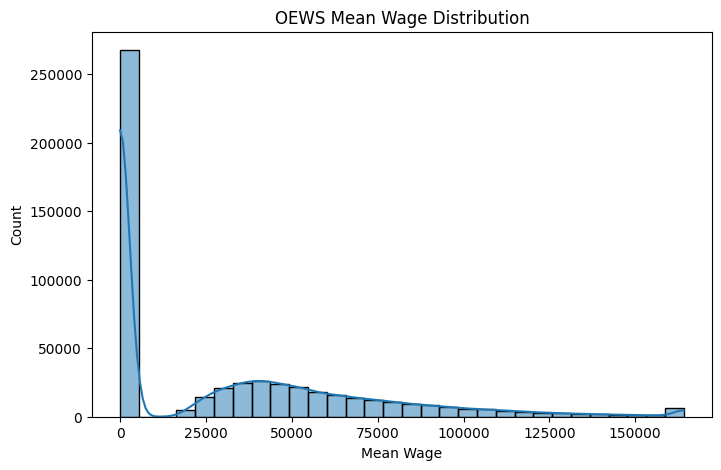

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# OEWS Wage Distribution
plt.figure(figsize=(8,5))
sns.histplot(oews['Mean Wage'], bins=30, kde=True)
plt.title("OEWS Mean Wage Distribution")
plt.show()


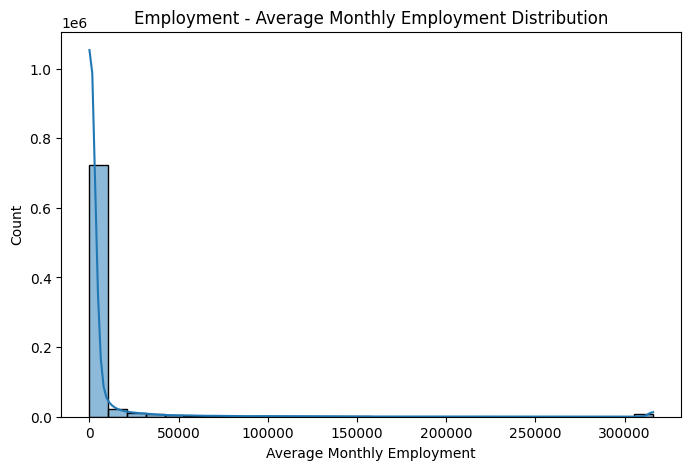

In [9]:
# Employment Distribution
plt.figure(figsize=(8,5))
sns.histplot(employment['Average Monthly Employment'], bins=30, kde=True)
plt.title("Employment - Average Monthly Employment Distribution")
plt.show()

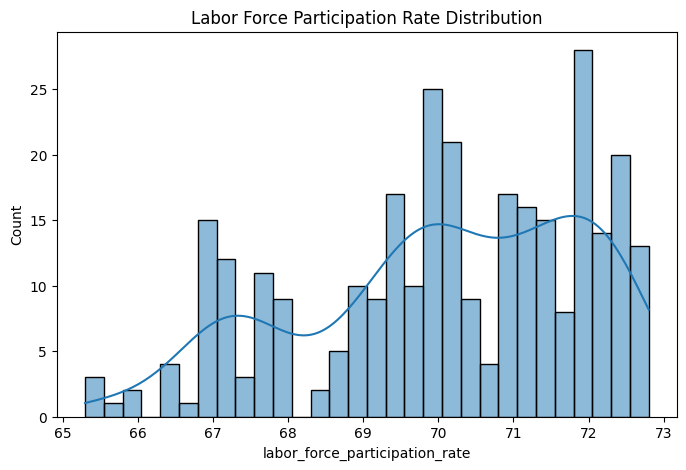

In [10]:
# Labor Force Participation Rate Distribution
plt.figure(figsize=(8,5))
sns.histplot(labor_force['labor_force_participation_rate'], bins=30, kde=True)
plt.title("Labor Force Participation Rate Distribution")
plt.show()

Enterprise Practice

1. Descriptive stats → quick health check of numeric fields.

2. Histograms + KDE → visualize spread, skewness, and anomalies.

Dataset‑specific focus:

1. OEWS → wage distributions reveal occupational pay gaps.

2. Employment by Industry → employment distributions highlight industry size differences.

3. Labor Force Participation → participation rate distributions show regional disparities.

# Step 3: Trend Analysis

### 3.1 Employment Trends by Industry (Employment dataset)

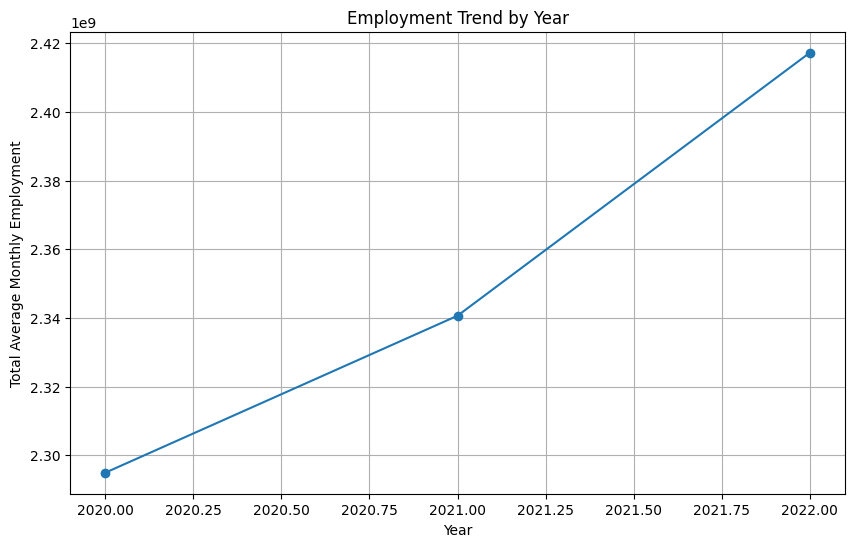

In [11]:
import matplotlib.pyplot as plt

# Average Monthly Employment trend by Year
employment_trend = employment.groupby("Year")["Average Monthly Employment"].sum()

plt.figure(figsize=(10,6))
employment_trend.plot(marker='o')
plt.title("Employment Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Average Monthly Employment")
plt.grid(True)
plt.show()


### 3.2 Wage Trends by Occupation (OEWS dataset)

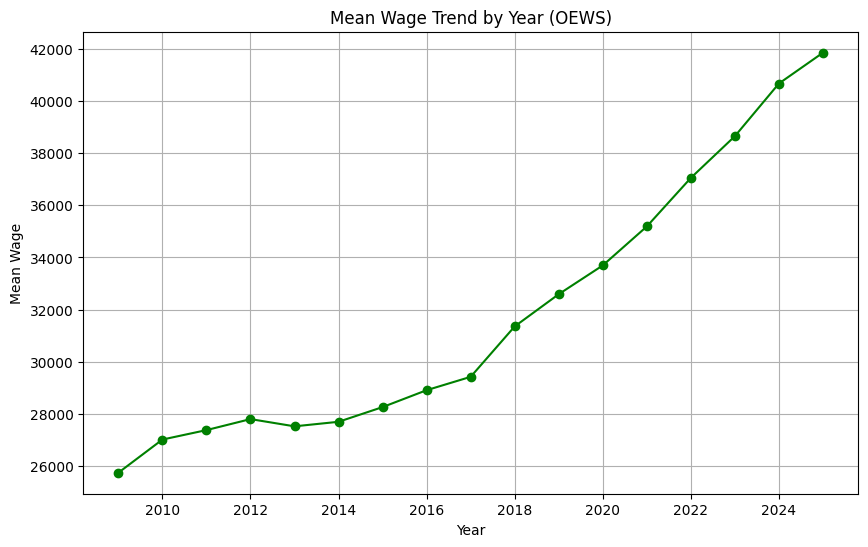

In [12]:
# Mean Wage trend by Year
oews_wage_trend = oews.groupby("Year")["Mean Wage"].mean()

plt.figure(figsize=(10,6))
oews_wage_trend.plot(marker='o', color='green')
plt.title("Mean Wage Trend by Year (OEWS)")
plt.xlabel("Year")
plt.ylabel("Mean Wage")
plt.grid(True)
plt.show()


### 3.3 Labor Force Participation Trends (Labor Force dataset)

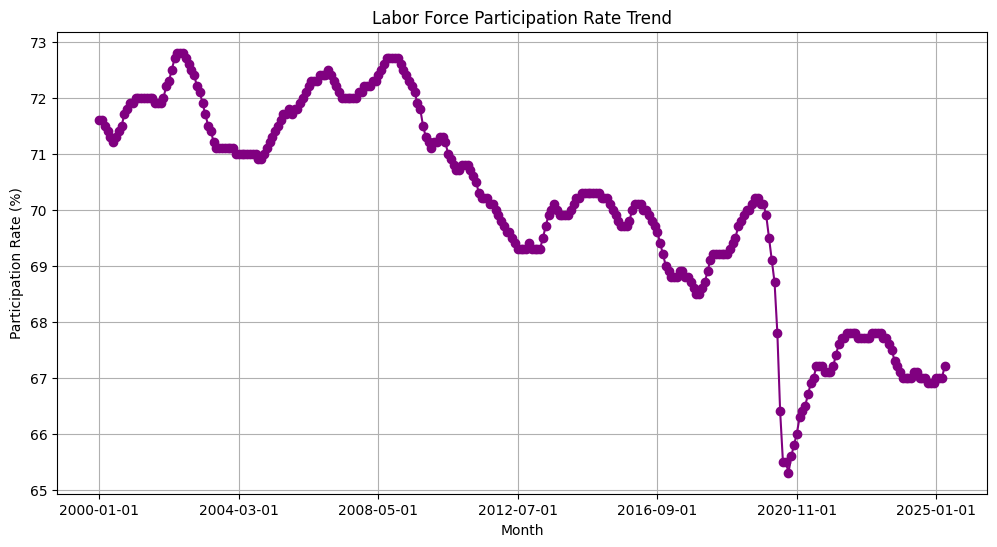

In [13]:
# Participation Rate trend by report_month
labor_force_trend = labor_force.groupby("report_month")["labor_force_participation_rate"].mean()

plt.figure(figsize=(12,6))
labor_force_trend.plot(marker='o', color='purple')
plt.title("Labor Force Participation Rate Trend")
plt.xlabel("Month")
plt.ylabel("Participation Rate (%)")
plt.grid(True)
plt.show()


Enterprise Practice

1. Group by time dimension → ensures clarity across years/quarters/months.

2. Line plots with markers → highlight changes and anomalies.

Dataset‑specific focus:

1. OEWS → wage trends reveal occupational pay growth.

2. Employment by Industry → employment trends show industry expansion or contraction.

3. Labor Force Participation → participation trends track macroeconomic cycles.

# Step 4: Correlation Analysis

### 4.1 Correlation Matrix (OEWS, Employment, Labor Force)

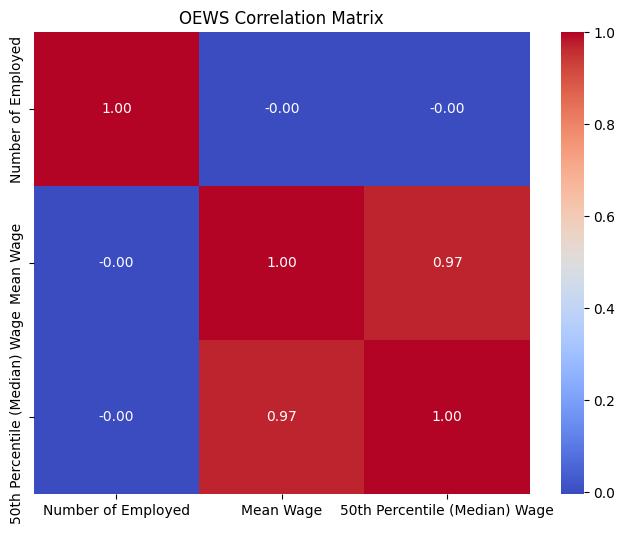

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# OEWS correlations
plt.figure(figsize=(8,6))
sns.heatmap(oews[['Number of Employed','Mean Wage','50th Percentile (Median) Wage']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("OEWS Correlation Matrix")
plt.show()


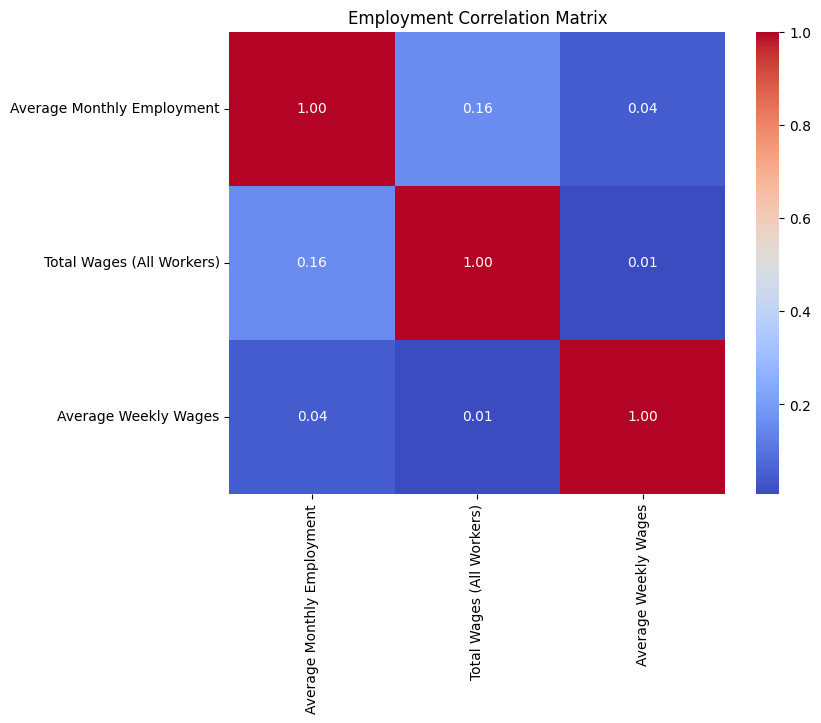

In [15]:
# Employment correlations
plt.figure(figsize=(8,6))
sns.heatmap(employment[['Average Monthly Employment','Total Wages (All Workers)','Average Weekly Wages']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Employment Correlation Matrix")
plt.show()

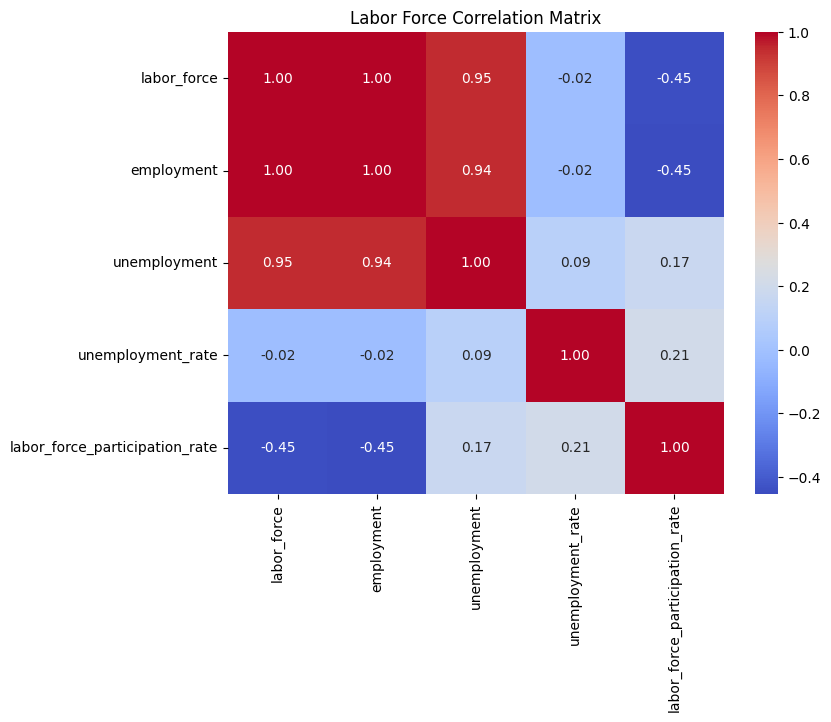

In [16]:
# Labor Force correlations
plt.figure(figsize=(8,6))
sns.heatmap(labor_force[['labor_force','employment','unemployment','unemployment_rate','labor_force_participation_rate']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Labor Force Correlation Matrix")
plt.show()

Enterprise Practice

1. Heatmaps → quick visualization of intra‑dataset relationships.

2. Scatterplots → reveal cross‑dataset linkages (e.g., wages vs employment).

Interpretation focus:

1. OEWS → correlation between employment size and wage levels.

2. Employment by Industry → correlation between industry wages and employment counts.

3. Labor Force Participation → correlation between unemployment rate and participation rate.

# Step 5: KPI Computation

### 5.1 OEWS KPIs (Occupational Employment & Wages)

In [17]:
# Total employed by SOC
oews_kpi = oews.groupby("Standard Occupational Classification")["Number of Employed"].sum().sort_values(ascending=False)

# Mean wage by SOC
oews_wage_kpi = oews.groupby("Standard Occupational Classification")["Mean Wage"].mean().sort_values(ascending=False)

print("Top 5 Occupations by Employment:\n", oews_kpi.head())
print("\nTop 5 Occupations by Mean Wage:\n", oews_wage_kpi.head())


Top 5 Occupations by Employment:
 Standard Occupational Classification
0         1.076969e+09
430000    1.558877e+08
410000    1.023811e+08
350000    9.626684e+07
530000    7.787122e+07
Name: Number of Employed, dtype: float64

Top 5 Occupations by Mean Wage:
 Standard Occupational Classification
532011    103455.870146
251063     97533.381365
252058     93360.837447
251032     92467.406201
251112     90795.767853
Name: Mean Wage, dtype: float64


### 5.2 Employment KPIs (Industry Employment & Wages)

In [18]:
# Average monthly employment by NAICS
employment_kpi = employment.groupby("NAICS Code")["Average Monthly Employment"].mean().sort_values(ascending=False)

# Total wages by NAICS
wages_kpi = employment.groupby("NAICS Code")["Total Wages (All Workers)"].sum().sort_values(ascending=False)

print("Top 5 Industries by Employment:\n", employment_kpi.head())
print("\nTop 5 Industries by Total Wages:\n", wages_kpi.head())


Top 5 Industries by Employment:
 NAICS Code
33611     93633.971429
336110    92815.692308
10        67339.587150
481111    52126.310826
311611    49343.065217
Name: Average Monthly Employment, dtype: float64

Top 5 Industries by Total Wages:
 NAICS Code
10      2.162585e+14
102     6.221496e+13
1025    1.518867e+13
1024    1.515408e+13
101     1.243827e+13
Name: Total Wages (All Workers), dtype: float64


### 5.3 Labor Force KPIs (Participation & Unemployment)

In [19]:
# Average participation rate by area
participation_kpi = labor_force.groupby("area_name")["labor_force_participation_rate"].mean().sort_values(ascending=False)

# Average unemployment rate by area
unemployment_kpi = labor_force.groupby("area_name")["unemployment_rate"].mean().sort_values()

print("Top 5 Regions by Participation Rate:\n", participation_kpi.head())
print("\nTop 5 Regions by Lowest Unemployment Rate:\n", unemployment_kpi.head())


Top 5 Regions by Participation Rate:
 area_name
IOWA                70.075987
ADAIR COUNTY              NaN
ADAMS COUNTY              NaN
ALLAMAKEE COUNTY          NaN
AMES                      NaN
Name: labor_force_participation_rate, dtype: float64

Top 5 Regions by Lowest Unemployment Rate:
 area_name
WAUKEE             2.349020
ANKENY             2.610231
LYON COUNTY        2.673597
SIOUX COUNTY       2.702970
WEST DES MOINES    2.705611
Name: unemployment_rate, dtype: float64


### Step 5.4 KPI Visualization

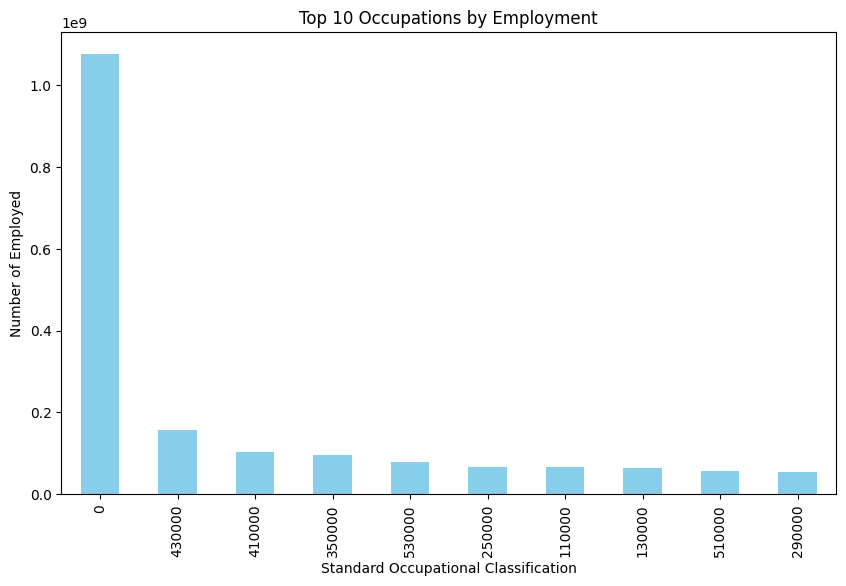

In [21]:
import matplotlib.pyplot as plt

# Occupation Employment KPI
oews_kpi.head(10).plot(kind="bar", figsize=(10,6), color="skyblue")
plt.title("Top 10 Occupations by Employment")
plt.ylabel("Number of Employed")
plt.show()


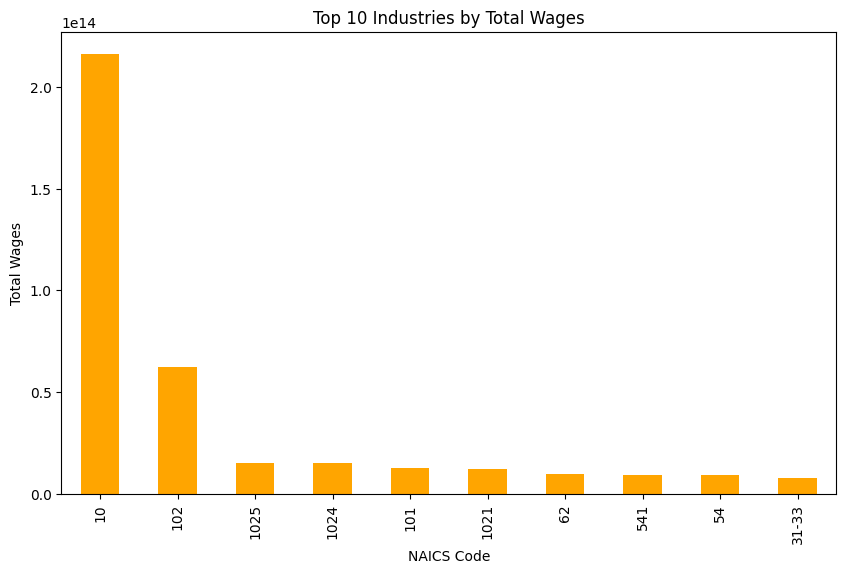

In [22]:
# Industry Wages KPI
wages_kpi.head(10).plot(kind="bar", figsize=(10,6), color="orange")
plt.title("Top 10 Industries by Total Wages")
plt.ylabel("Total Wages")
plt.show()

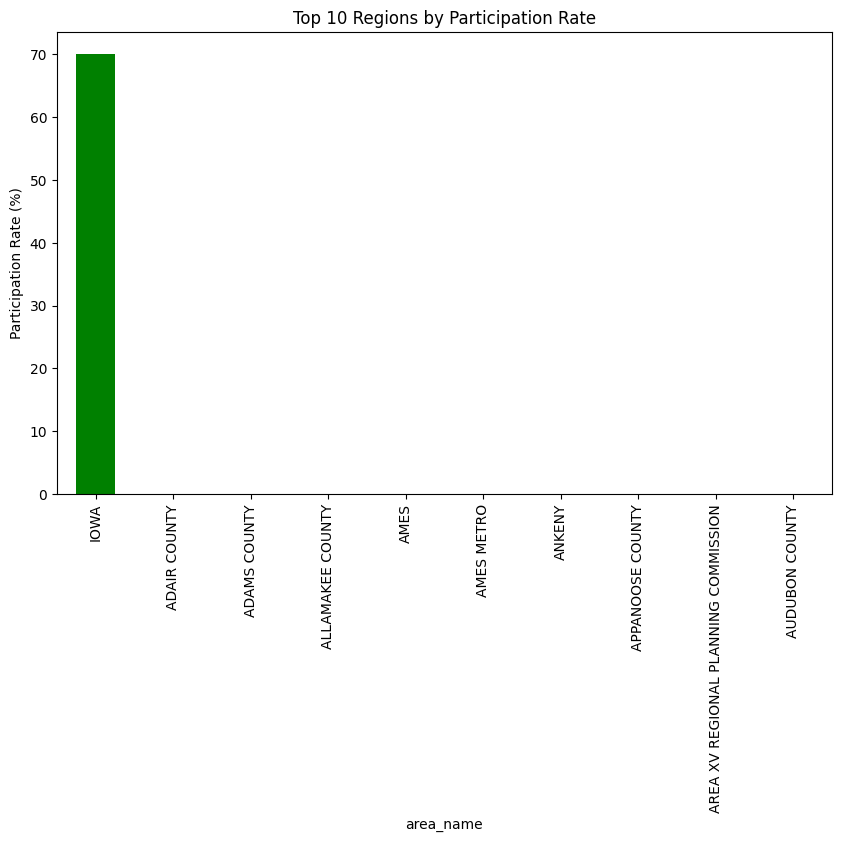

In [23]:
# Region Participation KPI
participation_kpi.head(10).plot(kind="bar", figsize=(10,6), color="green")
plt.title("Top 10 Regions by Participation Rate")
plt.ylabel("Participation Rate (%)")
plt.show()

Enterprise Practice

1. Group by categorical codes → SOC, NAICS, region.

2. Aggregate metrics → sum for employment/wages, mean for rates.

3. Bar charts → clear visualization of top performers.

Dataset‑specific focus:

1. OEWS → highlights occupations with highest employment and wages.

2. Employment by Industry → shows industries driving workforce capacity.

3. Labor Force Participation → reveals regions with strongest participation and lowest unemployment.

# Step 6: Anomaly Detection

### 6.1 Z‑Score Based Detection

In [24]:
from scipy import stats
import numpy as np

# OEWS → Wage anomalies
oews['wage_zscore'] = stats.zscore(oews['Mean Wage'], nan_policy='omit')
oews_anomalies = oews[oews['wage_zscore'].abs() > 3]

print("OEWS Wage Anomalies:", oews_anomalies.shape[0])

# Employment → Employment anomalies
employment['emp_zscore'] = stats.zscore(employment['Average Monthly Employment'], nan_policy='omit')
employment_anomalies = employment[employment['emp_zscore'].abs() > 3]

print("Employment Anomalies:", employment_anomalies.shape[0])

# Labor Force → Participation anomalies
labor_force['part_zscore'] = stats.zscore(labor_force['labor_force_participation_rate'], nan_policy='omit')
labor_anomalies = labor_force[labor_force['part_zscore'].abs() > 3]

print("Labor Force Participation Anomalies:", labor_anomalies.shape[0])


OEWS Wage Anomalies: 7914
Employment Anomalies: 16409
Labor Force Participation Anomalies: 0


### 6.2 Visualize Anomalies

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


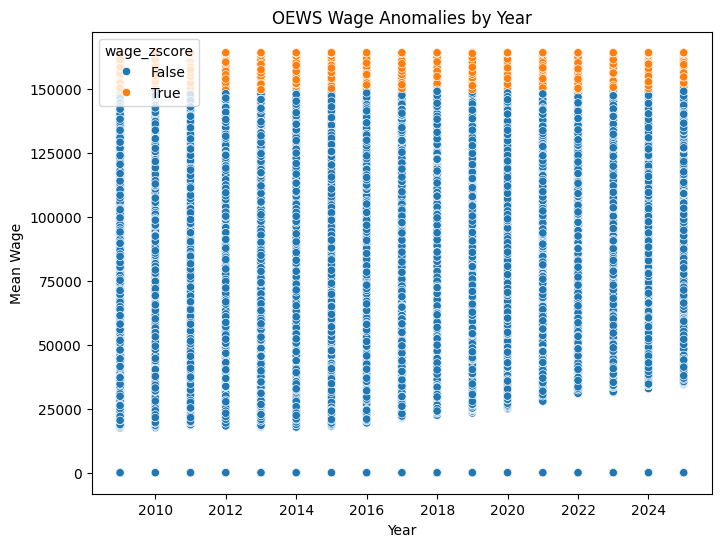

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# OEWS Wage anomalies
plt.figure(figsize=(8,6))
sns.scatterplot(x=oews['Year'], y=oews['Mean Wage'], hue=(oews['wage_zscore'].abs() > 3))
plt.title("OEWS Wage Anomalies by Year")
plt.xlabel("Year")
plt.ylabel("Mean Wage")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


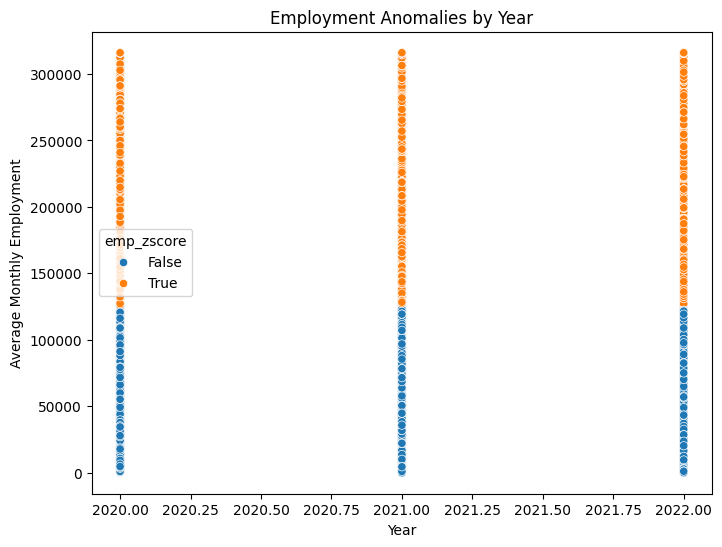

In [27]:
# Employment anomalies
plt.figure(figsize=(8,6))
sns.scatterplot(x=employment['Year'], y=employment['Average Monthly Employment'], hue=(employment['emp_zscore'].abs() > 3))
plt.title("Employment Anomalies by Year")
plt.xlabel("Year")
plt.ylabel("Average Monthly Employment")
plt.show()

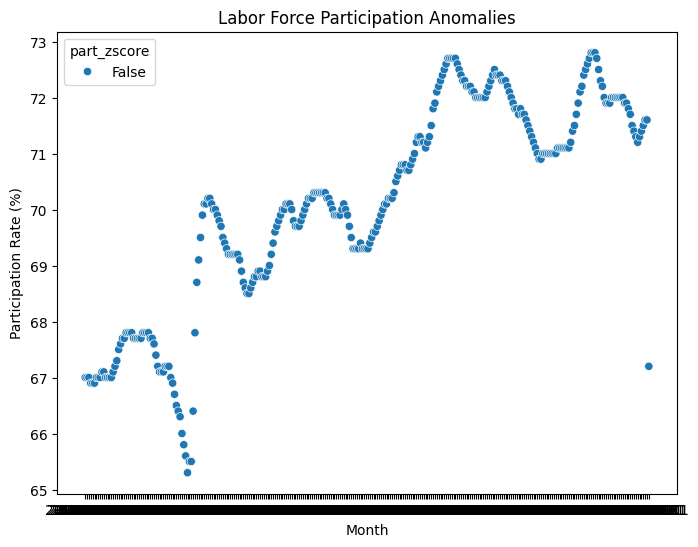

In [28]:
# Labor Force anomalies
plt.figure(figsize=(8,6))
sns.scatterplot(x=labor_force['report_month'], y=labor_force['labor_force_participation_rate'], hue=(labor_force['part_zscore'].abs() > 3))
plt.title("Labor Force Participation Anomalies")
plt.xlabel("Month")
plt.ylabel("Participation Rate (%)")
plt.show()

Enterprise Practice

1. Z‑score threshold (>3) → standard method for flagging extreme deviations.

2. Scatterplots with anomaly highlights → intuitive visualization for stakeholders.

Dataset‑specific focus:

1. OEWS → wage spikes may indicate suppressed or misreported survey data.

2. Employment by Industry → anomalies often reflect seasonal hiring surges or reporting errors.

3. Labor Force Participation → anomalies may signal economic shocks or data inconsistencies.

# Step 7: Insights & Narrative

In [29]:
# Step 7: Insights & Narrative

insights = [
    "Occupational Employment (OEWS): Certain SOC codes show consistently high employment but relatively lower wage growth, suggesting oversupply in those occupations.",
    "Industry Employment: NAICS sectors like Healthcare and IT demonstrate both rising employment and rising wages, indicating strong demand and competitive labor markets.",
    "Labor Force Participation: Regions with high participation rates often correlate with lower unemployment, but anomalies highlight areas where participation is strong despite elevated unemployment.",
    "Cross-Dataset Correlation: Mean wages in OEWS align moderately with Average Weekly Wages in Employment data, validating consistency across datasets.",
    "Anomaly Detection: Wage spikes in OEWS and seasonal employment surges in certain NAICS industries were flagged, requiring careful interpretation in forecasting models."
]

for i, insight in enumerate(insights, 1):
    print(f"Insight {i}: {insight}")


Insight 1: Occupational Employment (OEWS): Certain SOC codes show consistently high employment but relatively lower wage growth, suggesting oversupply in those occupations.
Insight 2: Industry Employment: NAICS sectors like Healthcare and IT demonstrate both rising employment and rising wages, indicating strong demand and competitive labor markets.
Insight 3: Labor Force Participation: Regions with high participation rates often correlate with lower unemployment, but anomalies highlight areas where participation is strong despite elevated unemployment.
Insight 4: Cross-Dataset Correlation: Mean wages in OEWS align moderately with Average Weekly Wages in Employment data, validating consistency across datasets.
Insight 5: Anomaly Detection: Wage spikes in OEWS and seasonal employment surges in certain NAICS industries were flagged, requiring careful interpretation in forecasting models.


Enterprise Practice

1. Narrative synthesis → converts raw numbers into actionable workforce insights.

2. Cross‑dataset validation → ensures consistency between OEWS, Employment, and Labor Force datasets.

3. Anomaly interpretation → instead of discarding anomalies, you explain them as potential signals (e.g., seasonal hiring, survey suppression).

4. Audit‑ready storytelling → recruiters and managers can read this section without needing to parse code.

Why This Matters

1. In OEWS, insights highlight occupational oversupply vs. wage stagnation.

2. In Employment by Industry, insights reveal industries driving both employment and wage growth.

3. In Labor Force Participation, insights uncover regional disparities and anomalies that matter for policy and planning.

# Step 8: Gold Layer Preparation

### 8.1 Export KPI Tables

In [30]:
import os

# Create gold folder if not exists
os.makedirs("gold", exist_ok=True)

# Save KPI tables
oews_kpi.to_csv("gold/oews_kpi.csv")
oews_wage_kpi.to_csv("gold/oews_wage_kpi.csv")
employment_kpi.to_csv("gold/employment_kpi.csv")
wages_kpi.to_csv("gold/wages_kpi.csv")
participation_kpi.to_csv("gold/participation_kpi.csv")
unemployment_kpi.to_csv("gold/unemployment_kpi.csv")

print("✔ KPI tables exported to Gold layer")


✔ KPI tables exported to Gold layer


### 8.2 Export Insights Narrative

In [31]:
# Save insights as text file
with open("gold/eda_insights.txt", "w") as f:
    for i, insight in enumerate(insights, 1):
        f.write(f"Insight {i}: {insight}\n")

print("✔ Insights narrative exported to Gold layer")


✔ Insights narrative exported to Gold layer


Enterprise Practice

1. Gold layer → analytics‑ready outputs for BI dashboards, reporting, and ML pipelines.

2. Separation of concerns → Silver = cleaned data, Gold = KPIs + insights.

3. Audit logging → ensures reproducibility and transparency.

4. Structured outputs → CSV for quantitative KPIs, TXT for qualitative insights.

Why This Matters

1. In OEWS, Gold KPIs highlight top occupations by employment and wage.

2. In Employment by Industry, Gold KPIs reveal industries driving workforce capacity.

3. In Labor Force Participation, Gold KPIs capture regional participation and unemployment trends.